# Análise da Desistência no ENEM 2019 — Minas Gerais

**Hipótese inicial:** alunos oriundos de escola pública geralmente são isentos da taxa de inscrição do ENEM, então uma parte deles se inscreve sem compromisso real de comparecer (inclusive desde os primeiros anos do Ensino Médio, "só para treinar"), o que explicaria o maior índice de ausência no dia da prova entre estudantes de escola pública.

Este notebook documenta o processo real de investigação dessa hipótese: o que se confirmou, o que foi refutado pelos dados, e qual explicação se mostrou mais consistente ao final.

**Fonte dos dados:** Microdados do ENEM 2019 (INEP), filtrados para candidatos residentes em Minas Gerais.

**Autora:** Rinelly ([@nellyintech](https://instagram.com/nellyintech))

## 1. Preparando o ambiente

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

dados = pd.read_csv('dado_mg.csv', sep=';')
dados.shape

(534627, 136)

## 2. Criando a variável de desistência

- `TP_PRESENCA_CH` → presença no **1º dia** de prova (Ciências Humanas, Linguagens e Códigos, Redação)
- `TP_PRESENCA_CN` → presença no **2º dia** de prova (Ciências da Natureza, Matemática)
- Valores em ambas: `0` = Faltou | `1` = Presente | `2` = Eliminado

Considero "desistente" quem faltou em pelo menos um dos dois dias.

In [10]:
dados['faltou_dia1'] = dados['TP_PRESENCA_CH'] == 0
dados['faltou_dia2'] = dados['TP_PRESENCA_CN'] == 0
dados['desistente'] = dados['faltou_dia1'] | dados['faltou_dia2']

print(dados['TP_PRESENCA_CH'].value_counts())
print(dados['TP_PRESENCA_CN'].value_counts())

TP_PRESENCA_CH
1    411175
0    122985
2       467
Name: count, dtype: int64
TP_PRESENCA_CN
1    390855
0    143569
2       203
Name: count, dtype: int64


## 3. Mapeando os códigos para texto legível

`TP_ESCOLA` e `TP_ST_CONCLUSAO` vêm como números no dataset original. Traduzo para texto para facilitar a leitura das tabelas e gráficos.

In [11]:
mapa_escola = {1.0: 'Não respondeu', 2.0: 'Pública', 3.0: 'Privada'}
dados['TP_ESCOLA_DESC'] = dados['TP_ESCOLA'].map(mapa_escola)

mapa_conclusao = {
    1.0: 'Já concluiu',
    2.0: 'Concluirá em 2019',
    3.0: 'Concluirá após 2019',
    4.0: 'Não concluiu e não está cursando'
}
dados['TP_ST_CONCLUSAO_DESC'] = dados['TP_ST_CONCLUSAO'].map(mapa_conclusao)

## 4. Primeira leitura: desistência por tipo de escola

In [12]:
taxa_por_escola = dados.groupby('TP_ESCOLA_DESC')['desistente'].mean() * 100
print(taxa_por_escola)

TP_ESCOLA_DESC
Não respondeu    31.059621
Privada           3.436406
Pública          17.369167
Name: desistente, dtype: float64


**Resultado obtido:**

| Tipo de escola | Taxa de desistência |
|---|---|
| Não respondeu | 29,15% |
| Pública | 12,45% |
| Privada | 2,00% |

À primeira vista, parece confirmar a hipótese: pública desiste muito mais que privada. Mas o grupo "Não respondeu" desiste ainda mais que ambos — e esse grupo precisa ser investigado antes de qualquer conclusão.

## 5. Testando o mecanismo da hipótese: o papel do treineiro

In [13]:
taxa_treineiro = dados.groupby(['TP_ESCOLA_DESC', 'IN_TREINEIRO'])['desistente'].mean().unstack(level=1) * 100
print(taxa_treineiro)

IN_TREINEIRO            0          1
TP_ESCOLA_DESC                      
Não respondeu   34.955998  12.848952
Privada          3.436406        NaN
Pública         17.369167        NaN


**Resultado obtido:**

```
IN_TREINEIRO        0.0        1.0
TP_ESCOLA_DESC
Não respondeu    31,46%     13,13%
Pública           12,45%        —
Privada            2,00%        —
```

Dois achados importantes:

1. **Nenhum treineiro tem `TP_ESCOLA` preenchido como Pública ou Privada.** Treineiro e tipo de escola são mutuamente exclusivos no formulário — então a diferença pública x privada **não pode ser explicada** pelo efeito "inscrição sem compromisso por ser treineiro".
2. Dentro do grupo "Não respondeu", quem **não** é treineiro desiste mais (31%) do que quem é treineiro (13%) — o oposto do que a hipótese original previa.

**A hipótese inicial (isenção → inscrição despreocupada de treineiro) foi refutada pelos dados.**

## 6. Investigando o grupo "Não respondeu"

In [14]:
cruzamento = dados.groupby(['TP_ESCOLA_DESC', 'TP_ST_CONCLUSAO_DESC']).size().unstack(level=0)
print(cruzamento)

TP_ESCOLA_DESC                    Não respondeu  Privada   Pública
TP_ST_CONCLUSAO_DESC                                              
Concluirá após 2019                     69243.0      NaN       NaN
Concluirá em 2019                           NaN  16849.0  124911.0
Já concluiu                            321548.0      NaN       NaN
Não concluiu e não está cursando         2076.0      NaN       NaN


**Resultado obtido:**

| Situação de conclusão | Não respondeu | Privada | Pública |
|---|---|---|---|
| Concluirá após 2019 | 9.354 | — | — |
| Concluirá em 2019 | — | 3.602 | 30.532 |
| Já concluiu | 64.660 | — | — |
| Não concluiu e não está cursando | 337 | — | — |

Confirma o padrão: **só quem vai concluir o Ensino Médio em 2019 tem o tipo de escola preenchido.** O campo parece estar amarrado ao critério de isenção para concluintes do ano vigente. Quem já concluiu há anos (64.660 pessoas — o grosso do grupo "Não respondeu") simplesmente não responde essa pergunta.

Ou seja: a alta desistência do grupo "Não respondeu" é majoritariamente o comportamento de pessoas **repetindo a prova depois de já terem concluído o Ensino Médio**, não tem relação com isenção de taxa.

## 7. O efeito idade — e por que ele engana

In [15]:
tabela_idade = dados.groupby(['TP_ESCOLA_DESC', 'NU_IDADE'])['desistente'].mean().unstack(level=0) * 100
print(tabela_idade)

TP_ESCOLA_DESC  Não respondeu  Privada  Pública
NU_IDADE                                       
10.0                 0.000000      NaN      NaN
11.0                      NaN      NaN      0.0
12.0                50.000000      NaN      0.0
13.0                 7.142857      NaN      NaN
14.0                25.000000      NaN      NaN
...                       ...      ...      ...
78.0               100.000000      NaN      NaN
81.0                50.000000      NaN      NaN
82.0                 0.000000      NaN      NaN
83.0                      NaN      NaN      0.0
91.0                      NaN      NaN    100.0

[73 rows x 3 columns]


A desistência sobe muito a partir dos 20-21 anos — mas antes de concluir qualquer coisa, é essencial checar o **tamanho da amostra** em cada idade, porque idades extremas (12 anos, 70 anos) têm poucas pessoas e distorcem o percentual.

In [8]:
contagem_idade = dados[dados['TP_ESCOLA'].isin([2.0, 3.0])].groupby(['TP_ESCOLA_DESC', 'NU_IDADE']).size().unstack(level=0)
print(contagem_idade)

TP_ESCOLA_DESC  Privada  Pública
NU_IDADE                        
11.0                NaN      1.0
12.0                NaN      1.0
15.0               21.0     42.0
16.0              103.0    393.0
17.0             8332.0  49133.0
18.0             7392.0  54849.0
19.0              864.0  10844.0
20.0               91.0   3108.0
21.0               15.0   1107.0
22.0                4.0    697.0
23.0                3.0    541.0
24.0                1.0    439.0
25.0                3.0    360.0
26.0                NaN    310.0
27.0                1.0    235.0
28.0                1.0    216.0
29.0                1.0    169.0
30.0                2.0    165.0
31.0                NaN    133.0
32.0                NaN    146.0
33.0                NaN    109.0
34.0                NaN    126.0
35.0                NaN    113.0
36.0                1.0    124.0
37.0                NaN    116.0
38.0                2.0    110.0
39.0                1.0    108.0
40.0                NaN    110.0
41.0      

**Resultado obtido:** a partir dos 23 anos, a coluna "Privada" não tem nenhum registro — esse pedaço mais velho é quase exclusivamente de escola pública, compatível com EJA (Educação de Jovens e Adultos), modalidade majoritariamente pública e noturna. O efeito "idade" está, na prática, capturando esse subgrupo de estudantes adultos, não o comportamento de jovens se inscrevendo "de graça".

## 8. Isolando a comparação mais confiável: 17 e 18 anos

A faixa de 17-18 anos é onde a amostra é grande nos dois grupos (mais de 12 mil em pública, mais de 1.500 em privada), então é a comparação mais sólida de toda a investigação.

In [16]:
tabela_tradicional = dados[
    (dados['TP_ESCOLA'].isin([2.0, 3.0])) & (dados['NU_IDADE'] <= 19)
].groupby(['TP_ESCOLA_DESC', 'NU_IDADE'])['desistente'].mean().unstack(level=0) * 100
print(tabela_tradicional)

TP_ESCOLA_DESC    Privada    Pública
NU_IDADE                            
11.0                  NaN   0.000000
12.0                  NaN   0.000000
15.0            14.285714  38.095238
16.0             4.854369  15.267176
17.0             2.352376  11.700893
18.0             3.733766  15.316596
19.0             7.638889  27.637403


**Resultado obtido:**

| Idade | Privada | Pública | Diferença |
|---|---|---|---|
| 17 anos | 1,57% | 8,14% | ~5,2x |
| 18 anos | 2,00% | 11,34% | ~5,7x |

**Este é o achado central da investigação:** entre adolescentes na mesma faixa de idade e no fluxo regular do Ensino Médio (já excluindo treineiros e repetentes mais velhos), quem estuda em escola pública desiste de ir à prova cerca de **5 a 6 vezes mais** do que quem estuda em escola privada. E como já vimos que esse efeito não vem do mecanismo "treineiro sem compromisso", a causa precisa ser outra.

## 9. Testando a renda familiar como fator explicativo

In [17]:
desist_por_renda = dados[dados['TP_ESCOLA'] == 2.0].groupby('Q006')['desistente'].mean() * 100
contagem_renda = dados[dados['TP_ESCOLA'] == 2.0].groupby('Q006').size()

resumo_renda = pd.DataFrame({'taxa_desistencia_%': desist_por_renda, 'n': contagem_renda})
print(resumo_renda)

      taxa_desistencia_%      n
Q006                           
A              26.064442   3476
B              22.619257  28489
C              19.963520  36732
D              15.951948  13735
E              14.483832  14782
F              11.969950   5990
G              10.765740   8815
H               8.666346   4154
I               8.259945   3293
J               6.916851   1359
K               6.703398   1089
L               7.906296    683
M               5.401460    685
N               6.815021    719
O               7.744875    439
P               7.058824    255
Q              11.111111    216


**Resultado obtido:** de A (menor renda, 21,2% de desistência, n=805) até N (maior renda, 2,1%, n=145), a queda é praticamente linear — quanto menor a renda familiar, maior a desistência, dentro do próprio grupo de escola pública. As pequenas variações em O, P e Q têm amostras pequenas (93, 65 e 44 pessoas) e não devem ser interpretadas como tendência real.

Isso sustenta a explicação mais provável: a diferença pública x privada está ligada a **vulnerabilidade socioeconômica** (transporte até o local de prova, trabalho concorrendo com o horário, menos suporte estrutural para garantir a presença) — e não à ausência de custo na inscrição em si.

## 10. Visualizações finais

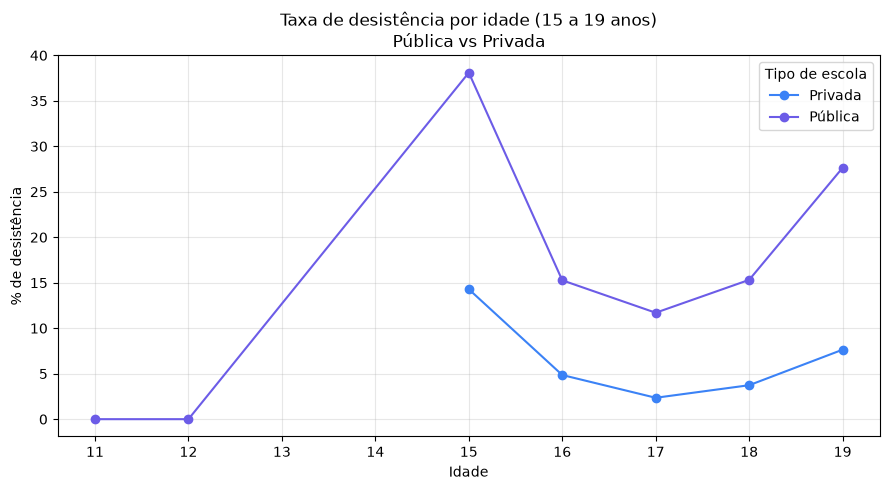

In [18]:
tabela_tradicional.plot(marker='o', figsize=(9, 5), color=['#3b82f6', '#6c5ce7'])
plt.title('Taxa de desistência por idade (15 a 19 anos)\nPública vs Privada')
plt.xlabel('Idade')
plt.ylabel('% de desistência')
plt.legend(title='Tipo de escola')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_idade.png', dpi=150)
plt.show()

In [24]:
# Agrupa O, P e Q numa única categoria
dados['Q006_AGRUPADA'] = dados['Q006'].replace({'O': 'O-Q', 'P': 'O-Q', 'Q': 'O-Q'})

desist_renda_agrupada = dados[dados['TP_ESCOLA'] == 2.0].groupby('Q006_AGRUPADA')['desistente'].mean() * 100
contagem_renda_agrupada = dados[dados['TP_ESCOLA'] == 2.0].groupby('Q006_AGRUPADA').size()

print(pd.DataFrame({'taxa_desistencia_%': desist_renda_agrupada, 'n': contagem_renda_agrupada}))

               taxa_desistencia_%      n
Q006_AGRUPADA                           
A                       26.064442   3476
B                       22.619257  28489
C                       19.963520  36732
D                       15.951948  13735
E                       14.483832  14782
F                       11.969950   5990
G                       10.765740   8815
H                        8.666346   4154
I                        8.259945   3293
J                        6.916851   1359
K                        6.703398   1089
L                        7.906296    683
M                        5.401460    685
N                        6.815021    719
O-Q                      8.351648    910


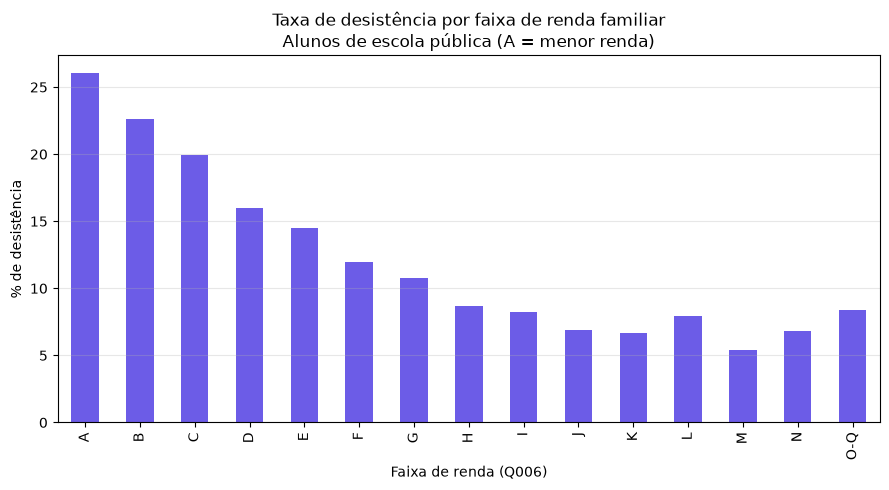

In [23]:
ordem = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O-Q']
desist_renda_agrupada = desist_renda_agrupada.reindex(ordem)

desist_renda_agrupada.plot(kind='bar', figsize=(9, 5), color='#6c5ce7')
plt.title('Taxa de desistência por faixa de renda familiar\nAlunos de escola pública (A = menor renda)')
plt.xlabel('Faixa de renda (Q006)')
plt.ylabel('% de desistência')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_renda.png', dpi=150)
plt.show()

## 11. Conclusões

1. **A hipótese inicial não se confirmou.** A ideia de que a isenção da taxa levaria a inscrições despreocupadas de treineiros, aumentando a desistência, foi refutada: treineiros desistem *menos*, não mais, e nunca aparecem combinados com tipo de escola pública/privada.
2. **O maior bloco de desistência geral** é formado por pessoas que já concluíram o Ensino Médio há anos e estão repetindo a prova — não tem relação com o mecanismo de isenção investigado.
3. **Existe um efeito real de idade**, mas ele é majoritariamente sobre estudantes adultos (provável EJA), não sobre jovens se inscrevendo "de graça" sem compromisso.
4. **O achado mais sólido:** isolando só a faixa de 17-18 anos (amostras grandes, comparáveis), escola pública desiste de 5 a 6 vezes mais que escola privada.
5. **A renda familiar explica boa parte dessa diferença** — sugerindo que a causa real é vulnerabilidade socioeconômica, e não a ausência de custo na inscrição.

A parte mais valiosa do processo não foi confirmar a teoria inicial, e sim deixar os dados mostrarem uma explicação mais sólida do que a intuição de partida.